In [58]:
import numpy as np
import pandas as pd
import seaborn as sns


In [29]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [31]:
df["customerID"].nunique()

7043

In [32]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [33]:
cols = ["Partner","Dependents","PhoneService","PaperlessBilling","Churn"]

for col in cols:
    df[col] = df[col].map({"Yes":1, "No":0})

In [34]:
df["gender"] = df["gender"].map({"Female":0, "Male":1})

In [35]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [36]:
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [37]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [38]:
df = df.dropna(subset=["TotalCharges"])

In [39]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [40]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = pd.get_dummies(df, columns=[
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract"
], drop_first=True)

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,False,False,False,False,False,False,False,False,False,False
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,False,True,False,False,False,False,False,False,True,False
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,False,False,False,False,False,False,False,False,False,False
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,False,True,False,True,False,False,False,False,True,False
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,False,False,False,False,False,False,False,False,False,False


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  
 17  

In [42]:
bool_cols = df.select_dtypes("bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [43]:
df = pd.get_dummies(df, columns=[
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "PaymentMethod"
], drop_first=True)

In [44]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
0,73.421502
1,26.578498


In [46]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [47]:
df.groupby("Contract")["Churn"].mean()

,Churn
Contract,
Month-to-month,0.427097
One year,0.112772
Two year,0.028487


In [48]:
df.groupby("Contract")["Churn"].value_counts()

Contract        Churn
Month-to-month  0        2220
                1        1655
One year        0        1306
                1         166
Two year        0        1637
                1          48
Name: count, dtype: int64

In [49]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
0,37.650010
1,17.979133


In [50]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
0,61.307408
1,74.441332


In [51]:
df.groupby("InternetService_Fiber optic")["Churn"].mean()

,Churn
InternetService_Fiber optic,
False,0.145325
True,0.418928


In [52]:
df["Churn"].mean()*100

np.float64(26.578498293515356)

In [53]:
df.groupby("gender")["Churn"].mean()

,Churn
gender,
0,0.269595
1,0.262046


In [54]:
df.groupby("SeniorCitizen")["Churn"].mean()

,Churn
SeniorCitizen,
0,0.236503
1,0.416813


In [55]:
df.groupby("Dependents")["Churn"].mean()

,Churn
Dependents,
0,0.312791
1,0.155312


In [56]:
df.groupby("PaperlessBilling")["Churn"].mean()

,Churn
PaperlessBilling,
0,0.163757
1,0.335893


In [57]:
df.groupby("PaymentMethod_Electronic check")["Churn"].mean()


,Churn
PaymentMethod_Electronic check,
False,0.170988
True,0.452854


<Axes: xlabel='Churn', ylabel='count'>

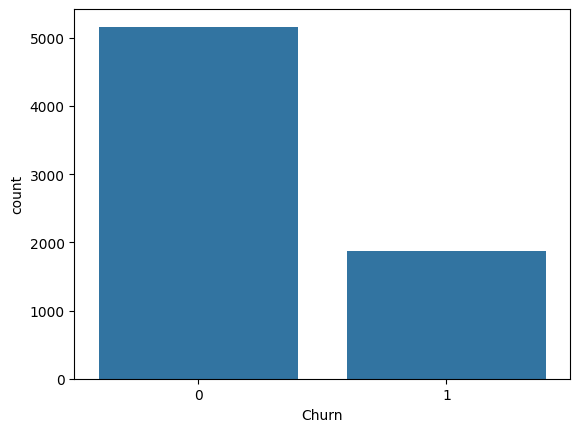

In [59]:
sns.countplot(x="Churn", data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

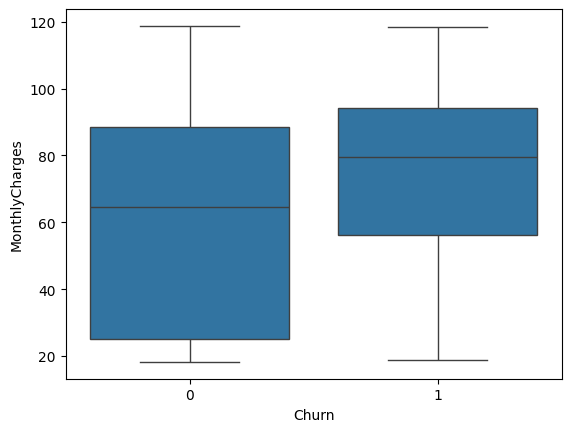

In [60]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

<Axes: xlabel='Contract', ylabel='count'>

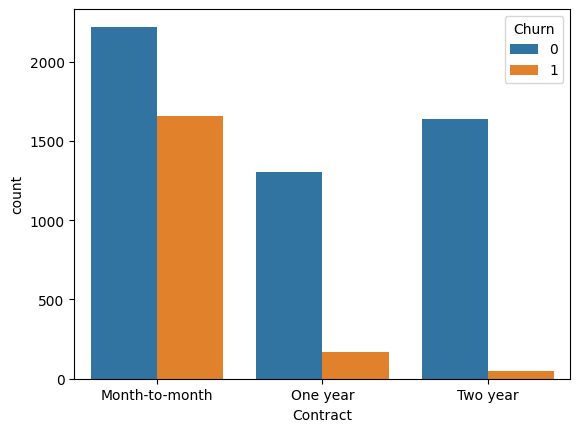

In [61]:
sns.countplot(x="Contract", hue="Churn", data=df)